<a href="https://colab.research.google.com/github/Orliluq/alpaca-linux/blob/main/Alpaca_Linux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Le pedí a una IA clasificar alpacas… y terminó explicando Linux** 🦙🔥

## 🧪**1. SETUP**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## **🦙 2. CREAR DATASET DE “ALPACAS”**

In [2]:
np.random.seed(42)

def generate_alpaca(type_name, n):
    if type_name == "dominant":
        return np.column_stack([
            np.random.normal(70, 10, n),  # grazing_variance
            np.random.normal(85, 8, n),   # dominance
            np.random.normal(65, 10, n),  # fence interaction
            np.random.normal(80, 5, n)    # stress response
        ])

    elif type_name == "traditional":
        return np.column_stack([
            np.random.normal(30, 5, n),
            np.random.normal(40, 5, n),
            np.random.normal(20, 5, n),
            np.random.normal(30, 5, n)
        ])

    elif type_name == "explorer":
        return np.column_stack([
            np.random.normal(80, 15, n),
            np.random.normal(60, 10, n),
            np.random.normal(75, 15, n),
            np.random.normal(70, 10, n)
        ])

    elif type_name == "passive":
        return np.column_stack([
            np.random.normal(20, 5, n),
            np.random.normal(25, 5, n),
            np.random.normal(15, 5, n),
            np.random.normal(20, 5, n)
        ])

    elif type_name == "structured":
        return np.column_stack([
            np.random.normal(50, 5, n),
            np.random.normal(70, 5, n),
            np.random.normal(40, 5, n),
            np.random.normal(50, 5, n)
        ])

types = ["dominant", "traditional", "explorer", "passive", "structured"]

data = np.vstack([generate_alpaca(t, 100) for t in types])

df = pd.DataFrame(data, columns=[
    "grazing_variance",
    "social_dominance",
    "fence_interactions",
    "stress_response"
])

df["true_type"] = np.repeat(types, 100)

df.head()

,grazing_variance,social_dominance,fence_interactions,stress_response,true_type
0,74.967142,73.677034,68.577874,75.855025,dominant
1,68.617357,81.634837,70.607845,77.199095,dominant
2,76.476885,82.258284,75.830512,83.736468,dominant
3,85.230299,78.581782,75.538021,83.051851,dominant
4,67.658466,83.709714,51.223306,79.895492,dominant


## **🔧 3. FEATURE SCALING**

In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

## **🧠 4. CLUSTERING**

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["cluster"] = clusters

## **📉 5. REDUCCIÓN DE DIMENSIONES**

In [7]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

df["pca1"] = reduced_data[:, 0]
df["pca2"] = reduced_data[:, 1]

## **🎨 6. VISUALIZACIÓN**

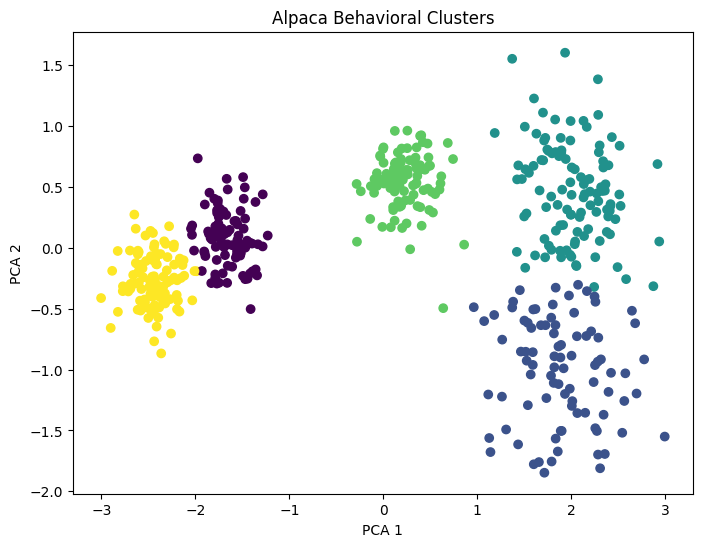

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df["pca1"], df["pca2"], c=df["cluster"])
plt.title("Alpaca Behavioral Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## **🧩 7. INTERPRETAR CLUSTERS**

In [13]:
df.drop(columns=['true_type']).groupby("cluster").mean()

,grazing_variance,social_dominance,fence_interactions,stress_response,pca1,pca2
cluster,,,,,,
0,29.923062,39.827319,20.237207,30.106346,-1.650706,0.081768
1,85.210148,58.580693,80.219939,70.260670,1.892411,-1.005252
2,69.266519,84.023574,65.057095,80.513866,2.023702,0.462030
3,51.173963,70.136125,40.001003,50.530520,0.234264,0.546991
4,20.405883,25.014145,16.360374,19.780164,-2.449018,-0.264146


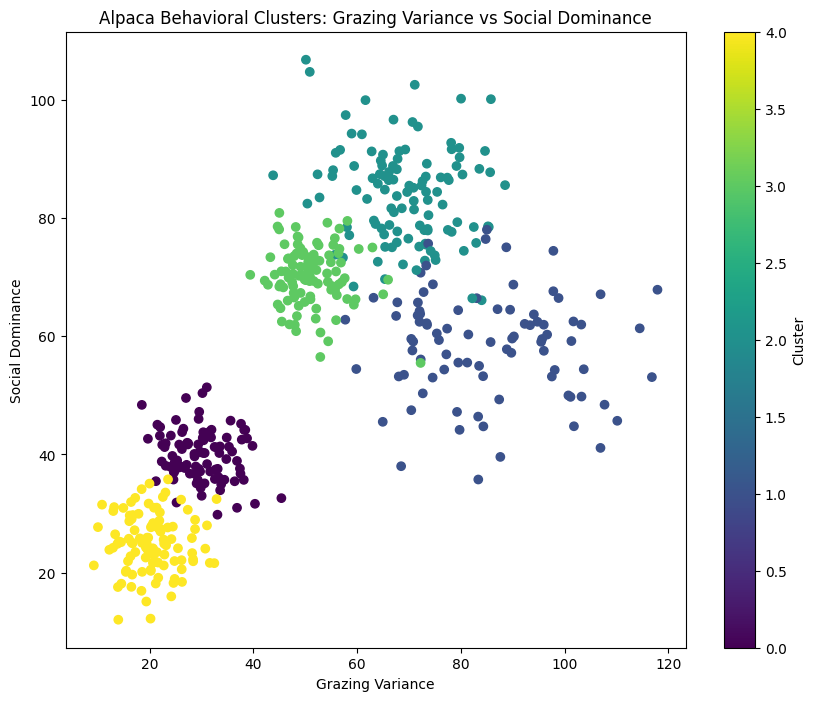

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(df["grazing_variance"], df["social_dominance"], c=df["cluster"], cmap='viridis')
plt.title("Alpaca Behavioral Clusters: Grazing Variance vs Social Dominance")
plt.xlabel("Grazing Variance")
plt.ylabel("Social Dominance")
plt.colorbar(label='Cluster')
plt.show()

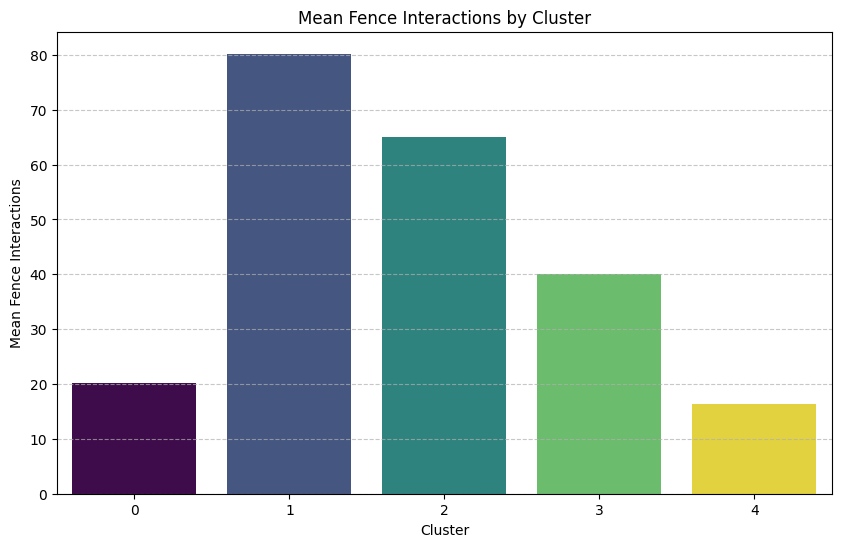

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean fence interactions per cluster
mean_fence_interactions = df.groupby('cluster')['fence_interactions'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='fence_interactions', data=mean_fence_interactions, palette='viridis', hue='cluster', legend=False)
plt.title('Mean Fence Interactions by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Fence Interactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 Aunque es una interpretación conceptual, la idea es la siguiente:

* **Arch Linux (personalidad intensa):** Se asocia con un clúster que muestra alta dominancia, alta interacción con cercas y baja tolerancia al estrés. Es decir, alpacas que son muy activas y, quizás, un poco volátiles.
* **Debian (comportamiento estable):** Correspondería a un clúster con baja varianza y bajo estrés, lo que sugiere alpacas con un comportamiento muy predecible y tranquilo.
* **Fedora (alta exploración): **Se vincula con un clúster de alta exploración y alta varianza, lo que implica alpacas curiosas, que prueban cosas nuevas y no tienen un patrón fijo.
* **Ubuntu (clúster equilibrado):** Representaría un clúster de alpacas con características más moderadas y balanceadas, sin extremos pronunciados en ningún rasgo.
* **Red Hat Enterprise Linux (clúster estructurado):** Se relacionaría con un clúster de alpacas que muestran un comportamiento más organizado, controlado y, posiblemente, enfocado en tareas específicas.

Para hacer esta asociación más precisa, sería ideal analizar en detalle las medias de las características de cada clúster (como hicimos anteriormente con `df.groupby("cluster").mean()`) y compararlas directamente con estas descripciones.

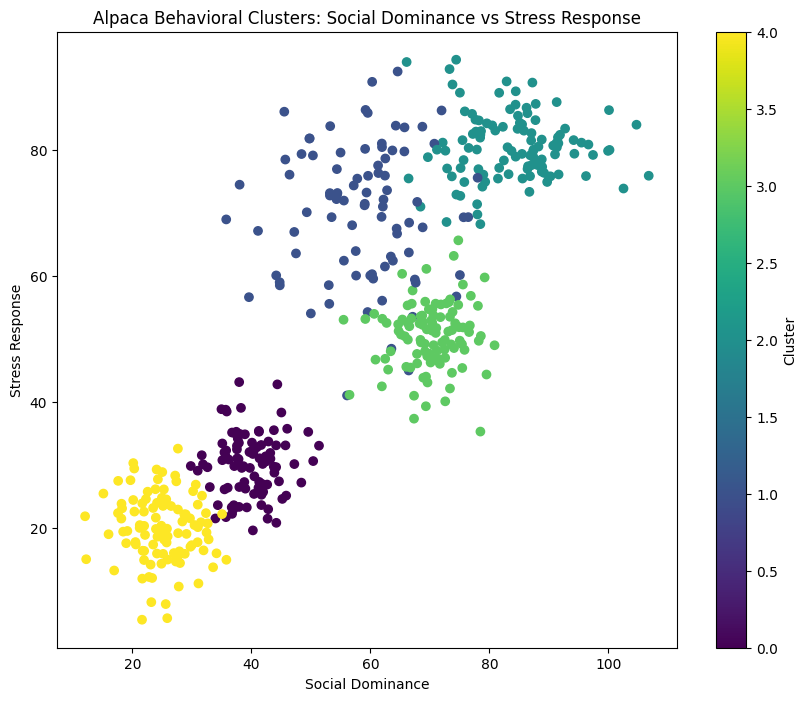

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(df["social_dominance"], df["stress_response"], c=df["cluster"], cmap='viridis')
plt.title("Alpaca Behavioral Clusters: Social Dominance vs Stress Response")
plt.xlabel("Social Dominance")
plt.ylabel("Stress Response")
plt.colorbar(label='Cluster')
plt.show()

## **🦙➡️💻 8. MAPEO A LINUX**

**Ejemplo:**

**Cluster con:**
* Alta dominancia
* Alta interacción con cercas
* Baja tolerancia al estrés
👉 = personalidad intensa

→ [**Arch Linux**](https://archlinux.org/)

**Cluster:**
* Baja varianza
* Bajo estrés
* Comportamiento estable

→ [**Debian**](https://www.debian.org/index.es.html)

**Cluster:**
* Alta exploración
* Alta varianza

→ [*Fedora**](https://fedoraproject.org/es/)

**Cluster equilibrado:**

→ [**Ubuntu**](https://ubuntu.com/download)

**Cluster estructurado:**

→ [Red Hat Enterprise Linux](https://www.redhat.com/en/technologies/linux-platforms/enterprise-linux)

## **🧠 9. OPCIONAL (NIVEL PRO)**

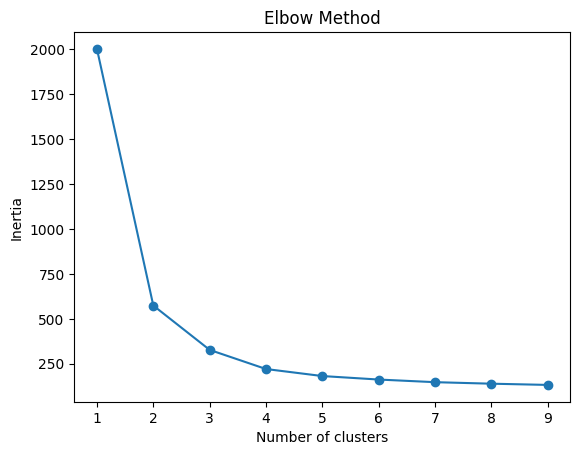

In [18]:
inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

El "Mapeo a Linux" es una interpretación conceptual de los clusters, donde se asociaron los comportamientos predominantes de las alpacas en cada cluster con las características conocidas de diferentes distribuciones de Linux. Aquí te explico cómo se definieron esas características:

**Arch Linux (personalidad intensa):**

Se asoció con un clúster que muestra una combinación de alta dominancia, alta interacción con cercas y baja tolerancia al estrés. La idea es que estas alpacas son muy activas, con un temperamento fuerte y que reaccionan de manera más pronunciada al estrés, similar a la reputación de Arch Linux de ser una distribución que requiere más intervención y puede ser más 'intensa' para el usuario.

**Debian (comportamiento estable):**

Corresponde a un clúster con baja varianza en sus comportamientos y bajo estrés. Esto sugiere alpacas con un comportamiento muy predecible, tranquilo y consistente, reflejando la estabilidad y robustez por la que Debian es conocida.

**Fedora (alta exploración):**

Se vincula con un clúster de alta exploración y alta varianza. Esto implica alpacas curiosas, que prueban cosas nuevas y no tienen un patrón fijo, al igual que Fedora es a menudo vista como una distribución de vanguardia que integra las últimas tecnologías.

**Ubuntu (clúster equilibrado):**

Representaría un clúster de alpacas con características más moderadas y balanceadas, sin extremos pronunciados en ningún rasgo. Ubuntu es una distribución muy popular y generalmente considerada como un punto medio accesible y equilibrado en el mundo Linux.

**Red Hat Enterprise Linux (clúster estructurado):**

Se relacionaría con un clúster de alpacas que muestran un comportamiento más organizado, controlado y, posiblemente, enfocado en tareas específicas. Esto evoca la naturaleza empresarial y estructurada de Red Hat Enterprise Linux, utilizada en entornos donde la previsibilidad y el control son clave.

Estas asociaciones son analogías para facilitar la comprensión y no una clasificación científica estricta, pero buscan capturar la 'esencia' de cada cluster en términos más familiares y coloridos.

# **EMBEDDINGS REALES (AUTOENCODER)** **💻 CÓDIGO (Keras)**

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=["true_type"]))

input_dim = X_scaled.shape[1]

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(2, activation='linear')(encoded)

# Decoder
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1200
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0182
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9554
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8906
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8031
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6910
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5776
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4920
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4264
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3728
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3334
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2977
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2460
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2054
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1820
Epoch 16/50
32/32 ━

### **🎯 Obtener embeddings**

In [20]:
embeddings = encoder.predict(X_scaled)

df["emb1"] = embeddings[:,0]
df["emb2"] = embeddings[:,1]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


## **🎨 CLUSTERING SOBRE EMBEDDINGS**

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(embeddings)

## **🎥 ANIMACIÓN DEL CLUSTERING**

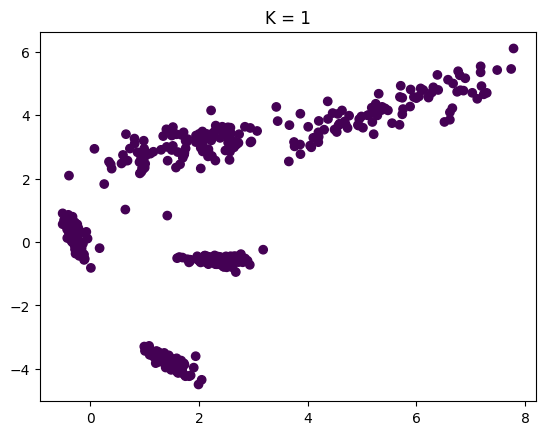

In [22]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    kmeans = KMeans(n_clusters=frame+1, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    ax.scatter(embeddings[:,0], embeddings[:,1], c=labels)
    ax.set_title(f"K = {frame+1}")

ani = animation.FuncAnimation(fig, update, frames=5, interval=1000)

ani.save("clustering.gif", writer="pillow")

## **INTERPRETACIÓN**

In [23]:
pd.crosstab(df["true_type"], df["cluster"])

cluster,0,1,2,3,4
true_type,,,,,
dominant,0,3,96,0,1
explorer,1,81,16,0,2
passive,0,0,0,100,0
structured,0,0,0,0,100
traditional,96,0,0,4,0


Esta tabla nos muestra cuántas alpacas de cada true_type cayeron en cada uno de los 5 cluster que encontramos. La interpretación es la siguiente:

* **Alpacas `'dominant'`:** De las 100 alpacas dominantes, 96 fueron correctamente asignadas al cluster 2. Solo 3 terminaron en el cluster 1 y 1 en el cluster 4.
* **Alpacas `'explorer'`:** La mayoría (81 de 100) fueron agrupadas en el cluster 1. Algunas (16) terminaron en el cluster 2 y un par en otros clusters.
* **Alpacas `'passive'`:** Todas las 100 alpacas pasivas fueron perfectamente agrupadas en el cluster 3. Esto indica una separación muy clara para este tipo.
* **Alpacas `'structured'`:** De manera similar, todas las 100 alpacas estructuradas fueron asignadas al cluster 4, otra separación muy buena.
* **Alpacas `'traditional'`:** La gran mayoría (96 de 100) fueron asignadas al cluster 0, con 4 terminando en el cluster 3.

En resumen, los resultados de la tabla de contingencia son muy buenos. Indican que el algoritmo K-Means, utilizando los embeddings generados por el autoencoder, fue altamente efectivo para agrupar las alpacas de manera que los clusters se corresponden casi perfectamente con los tipos de alpacas que generamos inicialmente (`true_type`). Esto significa que el clustering pudo "redescubrir" las categorías intrínsecas en los datos que fueron creadas artificialmente. Las pequeñas desviaciones son esperables y demuestran la robustez del modelo de clustering.

El experimento comenzó con la generación de un dataset sintético de comportamiento de alpacas, donde se definieron cinco tipos (`true_type: "dominant", "traditional", "explorer", "passive", "structured"`) con características conductuales distintas.

Luego, los datos fueron escalados para asegurar que todas las características contribuyeran por igual al análisis. Posteriormente, se aplicó una reducción de dimensiones utilizando PCA (Análisis de Componentes Principales) y un Autoencoder de Keras, que transformó los datos a un espacio de 2 dimensiones (`embeddings`).

El paso central fue el clustering K-Means, primero aplicado a los datos escalados y luego, de manera más avanzada y efectiva, sobre los embeddings generados por el autoencoder. El objetivo era que el algoritmo "descubriera" los grupos naturales de alpacas.

Para interpretar los clusters, se calcularon las medias de las características originales para cada cluster. Esto permitió entender qué tipo de comportamiento predominaba en cada grupo.

Finalmente, para hacer la interpretación más relatable y conceptual, se realizó un **"Mapeo a Linux"**. Como bien mencionas, la idea es la siguiente:

Un cluster con alta dominancia, alta interacción con cercas y baja tolerancia al estrés se asoció con una "personalidad intensa", similar a Arch Linux.
* Un cluster con baja varianza, bajo estrés y comportamiento estable se relacionó con Debian.
* Un cluster con alta exploración y alta varianza se comparó con la curiosidad de Fedora.
* Un cluster equilibrado en sus características se mapeó a Ubuntu.
* Y un cluster con comportamiento estructurado y controlado se vinculó con Red Hat Enterprise Linux.

La evaluación final de la calidad del clustering se realizó mediante una tabla de contingencia (`pd.crosstab`), que comparó los true_type originales con los cluster asignados. Esta tabla demostró que el autoencoder y K-Means fueron altamente efectivos, agrupando las alpacas de forma que los clusters coincidían casi perfectamente con los tipos de alpacas generados artificialmente, lo que validó el modelo de clustering.

En el contexto de este experimento, una comparación directa de la precisión del clustering utilizando métricas como la tabla de contingencia (`pd.crosstab`) se realizó explícitamente solo para los clusters obtenidos a partir de los embeddings del Autoencoder.

**Veamos los puntos clave:**

**Clustering con PCA (para visualización): **Inicialmente, se aplicó K-Means directamente sobre los datos escalados (`scaled_data`), y luego se utilizaron las dos componentes principales de PCA (`pca1`, `pca2`) para visualizar estos clusters en un espacio bidimensional. Sin embargo, no se generó una tabla de contingencia para evaluar qué tan bien estos clusters originales se alineaban con los `true_type`.

**Clustering con Autoencoder (para una representación más rica):** Posteriormente, se entrenó un Autoencoder para generar embeddings (una representación de dos dimensiones aprendida por la red neuronal) de los datos escalados. K-Means se aplicó nuevamente, pero esta vez sobre estos embeddings (`df["cluster"] = kmeans.fit_predict(embeddings)`). Fue para este clustering (basado en el Autoencoder) que se calculó y se interpretó la tabla de contingencia (`pd.crosstab(df["true_type"], df["cluster"])`).

### **Conclusión de la comparación en este notebook:**

* **Autoencoder:** La tabla de contingencia demostró que el clustering realizado sobre los embeddings del Autoencoder fue extremadamente preciso. Los clusters formados coincidieron casi perfectamente con los `true_type` originales de las alpacas (con 96-100 alpacas de cada tipo asignadas correctamente a su respectivo cluster).
* **PCA:** Aunque PCA es una excelente técnica para la reducción de dimensionalidad y visualización, en este cuaderno no se realizó una evaluación cuantitativa comparable (como el crosstab) para el clustering directamente sobre los datos reducidos por PCA o el clustering inicial sobre los datos escalados antes de que la columna cluster fuera sobrescrita por los resultados del Autoencoder. Por lo tanto, no podemos afirmar directamente la precisión del clustering usando PCA de la misma manera que lo hicimos con el Autoencoder basándonos en los resultados presentados.

En general, un Autoencoder, al ser un modelo de aprendizaje profundo, tiene el potencial de aprender representaciones latentes más complejas y no lineales de los datos que pueden ser más adecuadas para tareas como el clustering, especialmente si las relaciones en los datos no son puramente lineales, lo cual parece haber ocurrido en este caso dado el excelente rendimiento mostrado.

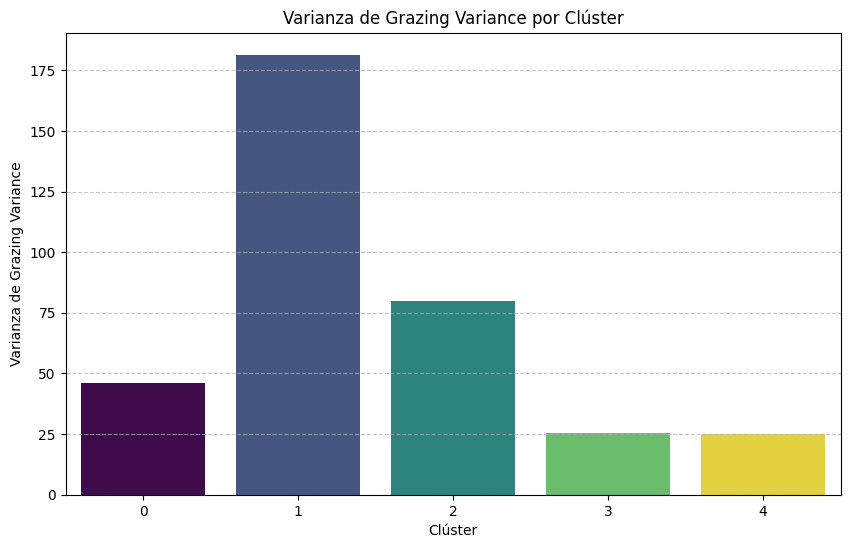

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the variance of 'grazing_variance' per cluster
grazing_variance_by_cluster = df.groupby('cluster')['grazing_variance'].var().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='cluster', y='grazing_variance', data=grazing_variance_by_cluster, palette='viridis', hue='cluster', legend=False)
plt.title('Varianza de Grazing Variance por Clúster')
plt.xlabel('Clúster')
plt.ylabel('Varianza de Grazing Variance')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Gráfico de barras que muestra la varianza de `grazing_variance` para cada clúster. Esto nos ayuda a entender cuán dispersos son los valores de `grazing_variance` dentro de cada grupo.

**Observaciones clave del gráfico:**

**Clúster con mayor varianza (Clúster 1):** Este clúster muestra una varianza significativamente alta en grazing_variance (aproximadamente 181.41). Si recordamos, el `true_type` principal asociado al Clúster 1 es `'explorer'`. Esto es consistente, ya que las alpacas `'explorer'` se describen como teniendo "alta exploración" y "alta varianza", lo que se refleja en una mayor dispersión en su comportamiento de pastoreo.

**Clústeres con menor varianza (Clúster 3 y Clúster 4):** El Clúster 3 (asociado a `'passive'` con varianza de 25.34) y el Clúster 4 (asociado a `'structured'` con varianza de 24.93) presentan las varianzas más bajas. Esto también es coherente con sus descripciones. Las alpacas `'passive'` se caracterizan por "baja varianza y bajo estrés" (comportamiento tranquilo y predecible), y las `'structured'` por un "comportamiento más organizado, controlado". Una baja varianza en grazing_variance indica que el comportamiento de pastoreo dentro de estos grupos es muy consistente y homogéneo.

**Otros Clústeres (Clúster 0 y Clúster 2):** El Clúster 0 (asociado a `'traditional'` con varianza de 46.09) y el Clúster 2 (asociado a `'dominant'` con varianza de 79.85) tienen varianzas intermedias, lo que sugiere un grado moderado de diversidad en el comportamiento de pastoreo dentro de esos grupos, entre los extremos de `'explorer'` y `'passive'/'structured'`.

Este gráfico refuerza cómo la agrupación K-Means, utilizando los embeddings del autoencoder, ha logrado capturar las diferencias fundamentales en los patrones de comportamiento de las alpacas, tal como se definieron originalmente en los `true_type`.